In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = {}

p = Path(os.getcwd() + '/data')
for x in p.rglob("*"):
    data[str(x).split('.')[0].split('\\')[-1]] = pd.read_csv(x)


In [3]:
close = pd.concat(data).loc['close_in_sample']
close

,Unnamed: 0,openTime,1000SATSUSDT,1INCHUSDT,AAVEUSDT,ACEUSDT,ACHUSDT,ADAUSDT,AEVOUSDT,AGIXUSDT,...,UNIUSDT_ret,VETUSDT_ret,WAVESUSDT_ret,XLMUSDT_ret,XRPUSDT_ret,XTZUSDT_ret,YFIUSDT_ret,ZECUSDT_ret,ZILUSDT_ret,ZRXUSDT_ret
0,17170.0,2021-08-24 03:00:00+00:00,NaN,3.4244,407.24,NaN,NaN,2.8504,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17171.0,2021-08-24 04:00:00+00:00,NaN,3.4860,410.05,NaN,NaN,2.8841,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17172.0,2021-08-24 05:00:00+00:00,NaN,3.4745,408.44,NaN,NaN,2.8656,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17173.0,2021-08-24 06:00:00+00:00,NaN,3.4784,409.01,NaN,NaN,2.9226,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17174.0,2021-08-24 07:00:00+00:00,NaN,3.4604,407.70,NaN,NaN,2.9126,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17364,34534.0,2023-08-17 15:00:00+00:00,NaN,0.2601,58.40,NaN,0.01544,0.2686,NaN,0.1906,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17365,34535.0,2023-08-17 16:00:00+00:00,NaN,0.2629,58.98,NaN,0.01542,0.2695,NaN,0.1915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17366,34536.0,2023-08-17 17:00:00+00:00,NaN,0.2644,59.24,NaN,0.01546,0.2708,NaN,0.1925,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17367,34537.0,2023-08-17 18:00:00+00:00,NaN,0.2634,59.15,NaN,0.01545,0.2719,NaN,0.1924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
close.index = pd.to_datetime(close['openTime'])

In [5]:
close = close.drop(columns=['Unnamed: 0', 'openTime'])

In [6]:
returns = close.pct_change().shift(-1)

C:\Users\User\AppData\Local\Temp\ipykernel_11020\133736654.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change().shift(-1)


In [7]:
y = returns

In [8]:
new_data = {}

for key in data:
    print(data[key])

       Unnamed: 0                   openTime  1000SATSUSDT   1INCHUSDT  \
0           17170  2021-08-24 03:00:00+00:00           NaN    826561.0   
1           17171  2021-08-24 04:00:00+00:00           NaN   2444979.0   
2           17172  2021-08-24 05:00:00+00:00           NaN   1364778.0   
3           17173  2021-08-24 06:00:00+00:00           NaN   1066617.0   
4           17174  2021-08-24 07:00:00+00:00           NaN   1947516.0   
...           ...                        ...           ...         ...   
17364       34534  2023-08-17 15:00:00+00:00           NaN  17393546.0   
17365       34535  2023-08-17 16:00:00+00:00           NaN  11452748.0   
17366       34536  2023-08-17 17:00:00+00:00           NaN   2273447.0   
17367       34537  2023-08-17 18:00:00+00:00           NaN   1861308.0   
17368       34538  2023-08-17 19:00:00+00:00           NaN   1400020.0   

       AAVEUSDT  ACEUSDT      ACHUSDT      ADAUSDT  AEVOUSDT    AGIXUSDT  ...  \
0       13065.4      NaN      

In [9]:
data[key]

,Unnamed: 0,openTime,1000SATSUSDT,1INCHUSDT,AAVEUSDT,ACEUSDT,ACHUSDT,ADAUSDT,AEVOUSDT,AGIXUSDT,...,XRPUSDT,XTZUSDT,XVGUSDT,XVSUSDT,YFIUSDT,YGGUSDT,ZECUSDT,ZENUSDT,ZILUSDT,ZRXUSDT
0,17170,2021-08-24 03:00:00+00:00,NaN,1.271258e+06,2719757.693,NaN,NaN,3.555494e+07,NaN,NaN,...,2.533061e+07,2.034980e+06,NaN,NaN,1.330260e+06,NaN,7.573191e+05,590057.0987,1.433477e+06,8.971720e+05
1,17171,2021-08-24 04:00:00+00:00,NaN,4.127254e+06,2667157.084,NaN,NaN,5.034032e+07,NaN,NaN,...,2.528593e+07,1.126931e+07,NaN,NaN,5.366902e+05,NaN,1.100148e+06,674247.5949,1.185023e+06,9.505722e+05
2,17172,2021-08-24 05:00:00+00:00,NaN,1.906487e+06,1778284.889,NaN,NaN,3.095922e+07,NaN,NaN,...,1.652907e+07,1.635902e+07,NaN,NaN,5.919901e+05,NaN,7.447763e+05,762997.9922,1.481926e+06,9.625638e+05
3,17173,2021-08-24 06:00:00+00:00,NaN,1.689274e+06,2569893.883,NaN,NaN,5.941339e+07,NaN,NaN,...,2.510169e+07,5.573488e+06,NaN,NaN,6.911994e+05,NaN,1.104224e+06,844389.1770,1.237135e+06,1.000962e+06
4,17174,2021-08-24 07:00:00+00:00,NaN,3.062576e+06,2752821.553,NaN,NaN,4.100313e+07,NaN,NaN,...,3.979378e+07,3.730867e+06,NaN,NaN,6.898011e+05,NaN,7.981427e+05,604228.9459,1.463272e+06,4.365517e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17364,34534,2023-08-17 15:00:00+00:00,NaN,2.211608e+06,3319550.994,NaN,832595.88528,1.637069e+07,NaN,1.639506e+06,...,6.040490e+07,2.122731e+06,2.378787e+06,200495.5948,1.196945e+06,2.675880e+06,5.473784e+05,774621.4983,2.139593e+06,1.112710e+06
17365,34535,2023-08-17 16:00:00+00:00,NaN,1.551864e+06,2529457.490,NaN,693838.14993,1.116879e+07,NaN,1.437459e+06,...,5.055211e+07,1.306153e+06,9.957672e+05,231526.1629,1.090691e+06,2.122510e+06,4.824333e+05,814930.2192,1.356906e+06,8.737957e+05
17366,34536,2023-08-17 17:00:00+00:00,NaN,3.366282e+05,665576.209,NaN,100730.15840,2.730191e+06,NaN,4.979357e+05,...,3.593698e+07,2.959739e+05,4.678008e+05,157107.4731,3.316209e+05,9.159405e+05,1.766622e+05,242914.5825,4.877566e+05,2.772497e+05
17367,34537,2023-08-17 18:00:00+00:00,NaN,2.124564e+05,513442.683,NaN,99202.62560,4.243530e+06,NaN,2.657402e+05,...,1.153867e+07,1.809855e+05,4.238334e+05,93833.3849,2.588179e+05,6.990882e+05,9.319440e+04,175816.5783,1.654860e+05,2.177046e+05


In [10]:
pd.concat(data, axis=1)

bvolume_in_sample                                                      \
             Unnamed: 0                   openTime 1000SATSUSDT   1INCHUSDT   
0                 17170  2021-08-24 03:00:00+00:00          NaN    826561.0   
1                 17171  2021-08-24 04:00:00+00:00          NaN   2444979.0   
2                 17172  2021-08-24 05:00:00+00:00          NaN   1364778.0   
3                 17173  2021-08-24 06:00:00+00:00          NaN   1066617.0   
4                 17174  2021-08-24 07:00:00+00:00          NaN   1947516.0   
...                 ...                        ...          ...         ...   
17364             34534  2023-08-17 15:00:00+00:00          NaN  17393546.0   
17365             34535  2023-08-17 16:00:00+00:00          NaN  11452748.0   
17366             34536  2023-08-17 17:00:00+00:00          NaN   2273447.0   
17367             34537  2023-08-17 18:00:00+00:00          NaN   1861308.0   
17368             34538  2023-08-17 19:00:00+00:00          NaN   1400020.0   

                                                                        ...  \
       AAVEUSDT ACEUSDT      ACHUSDT      ADAUSDT AEVOUSDT    AGIXUSDT  ...   
0       13065.4     NaN          NaN   26091616.0      NaN         NaN  ...   
1       15213.4     NaN          NaN   34056127.0      NaN         NaN  ...   
2       10303.6     NaN          NaN   23626771.0      NaN         NaN  ...   
3       13418.8     NaN          NaN   40683928.0      NaN         NaN  ...   
4       15680.1     NaN          NaN   30082490.0      NaN         NaN  ...   
...         ...     ...          ...          ...      ...         ...  ...   
17364  119133.1     NaN  104357616.0  123288982.0      NaN  17694074.0  ...   
17365   87728.2     NaN   95059840.0   83557386.0      NaN  15520182.0  ...   
17366   22963.6     NaN   17072613.0   21760593.0      NaN   4869294.0  ...   
17367   18207.0     NaN   14788345.0   32237490.0      NaN   3012690.0  ...   
17368   12400.8     NaN   13047779.0   13253080.0      NaN   2201186.0  ...   

      takerbuyqvolume_in_sample                                           \
                        XRPUSDT       XTZUSDT       XVGUSDT      XVSUSDT   
0                  2.533061e+07  2.034980e+06           NaN          NaN   
1                  2.528593e+07  1.126931e+07           NaN          NaN   
2                  1.652907e+07  1.635902e+07           NaN          NaN   
3                  2.510169e+07  5.573488e+06           NaN          NaN   
4                  3.979378e+07  3.730867e+06           NaN          NaN   
...                         ...           ...           ...          ...   
17364              6.040490e+07  2.122731e+06  2.378787e+06  200495.5948   
17365              5.055211e+07  1.306153e+06  9.957672e+05  231526.1629   
17366              3.593698e+07  2.959739e+05  4.678008e+05  157107.4731   
17367              1.153867e+07  1.809855e+05  4.238334e+05   93833.3849   
17368              7.134958e+06  1.989099e+05  3.563089e+05   66102.2409   

                                                                            \
            YFIUSDT       YGGUSDT       ZECUSDT      ZENUSDT       ZILUSDT   
0      1.330260e+06           NaN  7.573191e+05  590057.0987  1.433477e+06   
1      5.366902e+05           NaN  1.100148e+06  674247.5949  1.185023e+06   
2      5.919901e+05           NaN  7.447763e+05  762997.9922  1.481926e+06   
3      6.911994e+05           NaN  1.104224e+06  844389.1770  1.237135e+06   
4      6.898011e+05           NaN  7.981427e+05  604228.9459  1.463272e+06   
...             ...           ...           ...          ...           ...   
17364  1.196945e+06  2.675880e+06  5.473784e+05  774621.4983  2.139593e+06   
17365  1.090691e+06  2.122510e+06  4.824333e+05  814930.2192  1.356906e+06   
17366  3.316209e+05  9.159405e+05  1.766622e+05  242914.5825  4.877566e+05   
17367  2.588179e+05  6.990882e+05  9.319440e+04  175816.5783  1.654860e+05   
17368  2.159108e+05  4.02

learning

In [11]:
training_data = pd.read_csv('data/full_data.csv', index_col='openTime')
training_data

,AAVEUSDT_close,ADAUSDT_close,ALGOUSDT_close,ATOMUSDT_close,AVAXUSDT_close,BALUSDT_close,BANDUSDT_close,BATUSDT_close,BCHUSDT_close,BLZUSDT_close,...,UNIUSDT_ret,VETUSDT_ret,WAVESUSDT_ret,XLMUSDT_ret,XRPUSDT_ret,XTZUSDT_ret,YFIUSDT_ret,ZECUSDT_ret,ZILUSDT_ret,ZRXUSDT_ret
openTime,,,,,,,,,,,,,,,,,,,,,
2020-10-22 08:00:00+00:00,0.080655,0.013746,0.026231,0.009071,0.001619,0.026409,0.022185,0.024669,0.011520,-0.018636,...,0.006766,0.034329,0.023537,0.002663,0.000382,0.003602,-0.021509,-0.003470,0.010769,0.000257
2020-10-22 12:00:00+00:00,0.014006,0.002565,0.011676,0.008072,-0.002959,-0.000078,-0.007739,0.002675,0.004971,0.035591,...,0.007273,0.004056,0.013823,-0.010856,-0.003436,-0.001346,-0.015865,0.003028,0.005074,-0.009245
2020-10-22 16:00:00+00:00,0.032058,0.015535,-0.008422,-0.010737,-0.016918,0.010167,0.015454,-0.004891,-0.001513,0.000923,...,-0.018695,0.004039,0.005020,-0.001635,-0.014559,-0.013926,0.001094,-0.009962,-0.014639,-0.011405
2020-10-22 20:00:00+00:00,-0.006103,-0.002160,-0.004089,0.002943,0.006665,-0.009059,-0.010430,-0.001787,-0.008872,-0.015785,...,-0.006142,-0.007225,0.002991,-0.003041,0.004666,0.002733,0.021065,-0.020125,-0.005123,0.000787
2020-10-23 00:00:00+00:00,0.013518,0.001263,0.009160,-0.007887,0.000092,-0.020861,-0.043295,-0.011638,0.002424,-0.026692,...,-0.014212,-0.004879,0.043374,-0.008328,-0.005805,-0.007269,-0.007878,-0.009647,0.002060,0.007860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-02 00:00:00+00:00,-0.069266,-0.041177,-0.047695,-0.032128,-0.067407,-0.046331,-0.049320,-0.052182,-0.056638,-0.033184,...,-0.012214,0.001145,0.002679,0.001148,0.007048,-0.001572,-0.005161,-0.000361,-0.010711,-0.006870
2024-04-02 04:00:00+00:00,-0.023231,0.000503,-0.003756,-0.007988,0.002710,-0.003753,0.000497,-0.003670,-0.007407,0.003680,...,-0.014008,-0.022399,-0.075237,-0.010780,-0.018497,-0.023622,-0.016649,-0.006496,-0.016241,-0.023992
2024-04-02 08:00:00+00:00,-0.020980,-0.017941,-0.015082,-0.014941,-0.019565,-0.024487,-0.022549,-0.025117,-0.012799,-0.008374,...,-0.014908,-0.002827,-0.063729,-0.012675,-0.011715,-0.011290,-0.007484,-0.012713,-0.008254,-0.019152


In [12]:
train_columns = []
test_columns = []

for col in training_data.columns:
    if "_ret" in col:
        test_columns.append(col)
    else:
        train_columns.append(col)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [14]:
window_size = 100

all_x = np.lib.stride_tricks.sliding_window_view(training_data.values, (window_size, training_data.shape[1]))[:, 0]
all_y = training_data[test_columns].iloc[99:]

In [15]:
x_test = all_x[-850:].view()
y_test = all_y[-850:].values.view()

In [16]:
x = all_x[:-(850 + 120)].view()
y = all_y[:-(850 + 120)].values.view()

In [17]:
val_len = 1000

In [18]:
val_start = x.shape[0] // 2 - val_len // 2
val_end = val_start + val_len

In [19]:
x_val = x[val_start: val_end]
y_val = y[val_start: val_end]

In [20]:
x_train = np.concatenate((x[:val_start - 100], x[val_end + 100:]))
y_train = np.concatenate((y[:val_start - 100], y[val_end + 100:]))

In [21]:
x_train.shape, x_val.shape, x_test.shape

((5282, 100, 630), (1000, 100, 630), (850, 100, 630))

In [22]:
y_train.shape, y_val.shape, y_test.shape

((5282, 63), (1000, 63), (850, 63))

In [23]:
x_train = torch.Tensor(x_train)
x_train = np.where(np.isinf(x_train), np.nan, x_train)
x_train = np.where(np.isnan(x_train), np.nanmean(x_train, axis=0), x_train)
x_train = torch.Tensor(x_train)

y_train = torch.Tensor(y_train)
y_train = np.where(np.isinf(y_train), np.nan, y_train)
y_train = np.where(np.isnan(y_train), np.nanmean(y_train, axis=0), y_train)
y_train = torch.Tensor(y_train)

x_val = torch.Tensor(x_val)
x_val = np.where(np.isinf(x_val), np.nan, x_val)
x_val = np.where(np.isnan(x_val), np.nanmean(x_val, axis=0), x_val)
x_val = torch.Tensor(x_val)

y_val = torch.Tensor(y_val)
y_val = np.where(np.isinf(y_val), np.nan, y_val)
y_val = np.where(np.isnan(y_val), np.nanmean(y_val, axis=0), y_val)
y_val = torch.Tensor(y_val)

x_test = torch.Tensor(x_test)
x_test = np.where(np.isinf(x_test), np.nan, x_test)
x_test = np.where(np.isnan(x_test), np.nanmean(x_test, axis=0), x_test)
x_test = torch.Tensor(x_test)

y_test = torch.Tensor(y_test)
y_test = np.where(np.isinf(y_test), np.nan, y_test)
y_test = np.where(np.isnan(y_test), np.nanmean(y_test, axis=0), y_test)
y_test = torch.Tensor(y_test)

C:\Users\User\AppData\Local\Temp\ipykernel_11020\2491588277.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_train = np.where(np.isinf(x_train), np.nan, x_train)
C:\Users\User\AppData\Local\Temp\ipykernel_11020\2491588277.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_train = np.where(np.isinf(y_train), np.nan, y_train)
C:\Users\User\AppData\Local\Temp\ipykernel_11020\2491588277.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pyt

In [24]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.activation = nn.ReLU()
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out)
        out = self.activation(out)

        return out

In [25]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, output_size),

        )
    def forward(self, x):
        x = x.contiguous().view(x.size(0), -1)
        return self.net(x)

In [26]:
input_size = x_train.shape[1] * x_train.shape[2]  # 100 * 630
hidden_size = 256
output_size = y_train.shape[1]                    # 63

model = MLP(input_size, hidden_size, output_size).to(device)


In [27]:
with torch.no_grad():
    out = model(x_train[:2].to(device))

out.shape

torch.Size([2, 63])

In [28]:
batch_size = 64

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False)


In [29]:
mse_loss = nn.MSELoss()
mae_loss = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [30]:
num_epochs = 10
train_mse, val_mse = [], []
for epoch in range(num_epochs):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = mse_loss(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    train_loss = total / n
    train_mse.append(train_loss)

    # VAL
    model.eval()
    total = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = mse_loss(pred, yb)

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    val_loss = total / n
    val_mse.append(val_loss)

    print(f"epoch {epoch+1}/{num_epochs}  train={train_loss:.6f}  val={val_loss:.6f}")



epoch 1/10  train=0.012235  val=0.000999
epoch 2/10  train=0.006781  val=0.001779
epoch 3/10  train=0.002655  val=0.000752
epoch 4/10  train=0.001035  val=0.000744
epoch 5/10  train=0.001695  val=0.000780
epoch 6/10  train=0.000900  val=0.000744
epoch 7/10  train=0.000730  val=0.000744
epoch 8/10  train=0.000730  val=0.000744
epoch 9/10  train=0.000730  val=0.000746
epoch 10/10  train=0.000730  val=0.000745


In [31]:
num_epochs = 20
train_mae, val_mae = [], []
for epoch in range(num_epochs):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = mae_loss(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

    train_loss = total / n
    train_mae.append(train_loss)

    # VAL
    model.eval()
    total = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

        pred = model(xb)
        loss = mae_loss(pred, yb)

        total += loss.item() * xb.size(0)
        n += xb.size(0)

    val_loss = total / n
    val_mae.append(val_loss)

    print(f"epoch {epoch+1}/{num_epochs}  train={train_loss:.6f}  val={val_loss:.6f}")



epoch 1/20  train=0.017061  val=0.020329
epoch 2/20  train=0.017043  val=0.020306
epoch 3/20  train=0.017012  val=0.019950
epoch 4/20  train=0.017024  val=0.019999
epoch 5/20  train=0.017005  val=0.020164
epoch 6/20  train=0.017016  val=0.019967
epoch 7/20  train=0.017019  val=0.019929
epoch 8/20  train=0.017010  val=0.020090
epoch 9/20  train=0.017012  val=0.020012
epoch 10/20  train=0.017007  val=0.019953
epoch 11/20  train=0.017012  val=0.019994
epoch 12/20  train=0.017011  val=0.020014
epoch 13/20  train=0.017007  val=0.020045
epoch 14/20  train=0.017012  val=0.019917
epoch 15/20  train=0.017032  val=0.019902
epoch 16/20  train=0.017009  val=0.020098
epoch 17/20  train=0.017028  val=0.019955
epoch 18/20  train=0.017024  val=0.020037
epoch 19/20  train=0.017007  val=0.019940
epoch 20/20  train=0.017018  val=0.020032


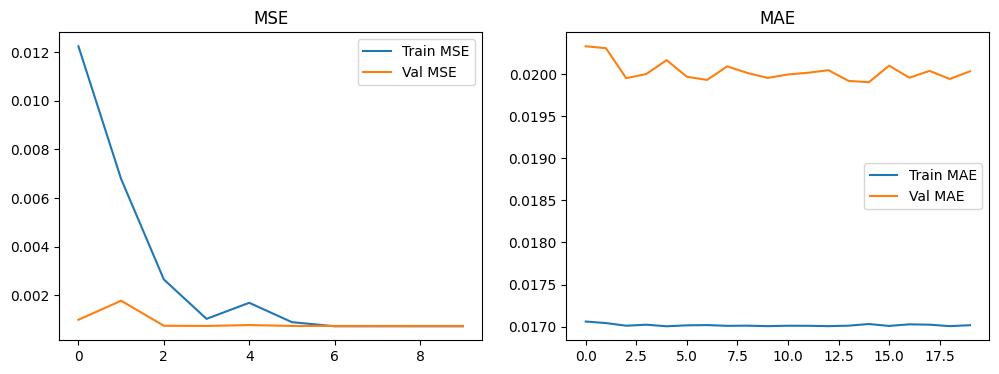

In [32]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_mse, label='Train MSE')
plt.plot(val_mse, label='Val MSE')
plt.legend()
plt.title('MSE')

plt.subplot(1,2,2)
plt.plot(train_mae, label='Train MAE')
plt.plot(val_mae, label='Val MAE')
plt.legend()
plt.title('MAE')

plt.show()
